In [3]:
import os

SOURCE_DIR = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

classes = sorted(os.listdir(SOURCE_DIR))
print(f"Number of classes: {len(classes)}")

class_counts = {}
for cls in classes:
    cls_path = os.path.join(SOURCE_DIR, cls)
    n_images = len(os.listdir(cls_path))
    class_counts[cls] = n_images

for cls, count in sorted(class_counts.items(), key=lambda x: x[1]):
    print(f"{cls}: {count}")

total = sum(class_counts.values())
min_count = min(class_counts.values())
max_count = max(class_counts.values())
print(f"\nTotal images: {total}")
print(f"Min class size: {min_count}")
print(f"Max class size: {max_count}")
print(f"Imbalance ratio (max/min): {max_count / min_count:.1f}")

Number of classes: 38
Potato___healthy: 152
Apple___Cedar_apple_rust: 275
Peach___healthy: 360
Raspberry___healthy: 371
Tomato___Tomato_mosaic_virus: 373
Grape___healthy: 423
Strawberry___healthy: 456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513
Apple___Black_rot: 621
Apple___Apple_scab: 630
Cherry_(including_sour)___healthy: 854
Tomato___Leaf_Mold: 952
Corn_(maize)___Northern_Leaf_Blight: 985
Pepper,_bell___Bacterial_spot: 997
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Tomato___Early_blight: 1000
Cherry_(including_sour)___Powdery_mildew: 1052
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
Strawberry___Leaf_scorch: 1109
Corn_(maize)___healthy: 1162
Grape___Black_rot: 1180
Corn_(maize)___Common_rust_: 1192
Grape___Esca_(Black_Measles): 1383
Tomato___Target_Spot: 1404
Pepper,_bell___healthy: 1478
Blueberry___healthy: 1502
Tomato___healthy: 1591
Apple___healthy: 1645
Tomato___Spider_mites Two-spotted_spider_mite: 1676
Tomato___Septoria_leaf_spot: 1771
Squash___Pow

In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split

SOURCE_DIR = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"
OUTPUT_DIR = "/kaggle/working/data_split"
SEED = 42

classes = sorted(os.listdir(SOURCE_DIR))

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

split_summary = {}

for cls in classes:
    cls_path = os.path.join(SOURCE_DIR, cls)
    images = os.listdir(cls_path)

    train_imgs, temp_imgs = train_test_split(
        images, train_size=0.6, random_state=SEED
    )
    val_imgs, test_imgs = train_test_split(
        temp_imgs, train_size=0.5, random_state=SEED
    )

    for img_name in train_imgs:
        src = os.path.join(cls_path, img_name)
        dst = os.path.join(OUTPUT_DIR, "train", cls, img_name)
        shutil.copyfile(src, dst)

    for img_name in val_imgs:
        src = os.path.join(cls_path, img_name)
        dst = os.path.join(OUTPUT_DIR, "val", cls, img_name)
        shutil.copyfile(src, dst)

    for img_name in test_imgs:
        src = os.path.join(cls_path, img_name)
        dst = os.path.join(OUTPUT_DIR, "test", cls, img_name)
        shutil.copyfile(src, dst)

    split_summary[cls] = {
        "train": len(train_imgs),
        "val": len(val_imgs),
        "test": len(test_imgs),
    }

for cls, counts in split_summary.items():
    print(f"{cls}: train={counts['train']}, val={counts['val']}, test={counts['test']}")

total_train = sum(v["train"] for v in split_summary.values())
total_val = sum(v["val"] for v in split_summary.values())
total_test = sum(v["test"] for v in split_summary.values())
print(f"\nTotal train: {total_train}")
print(f"Total val: {total_val}")
print(f"Total test: {total_test}")

Apple___Apple_scab: train=378, val=126, test=126
Apple___Black_rot: train=372, val=124, test=125
Apple___Cedar_apple_rust: train=165, val=55, test=55
Apple___healthy: train=987, val=329, test=329
Blueberry___healthy: train=901, val=300, test=301
Cherry_(including_sour)___Powdery_mildew: train=631, val=210, test=211
Cherry_(including_sour)___healthy: train=512, val=171, test=171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: train=307, val=103, test=103
Corn_(maize)___Common_rust_: train=715, val=238, test=239
Corn_(maize)___Northern_Leaf_Blight: train=591, val=197, test=197
Corn_(maize)___healthy: train=697, val=232, test=233
Grape___Black_rot: train=708, val=236, test=236
Grape___Esca_(Black_Measles): train=829, val=277, test=277
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): train=645, val=215, test=216
Grape___healthy: train=253, val=85, test=85
Orange___Haunglongbing_(Citrus_greening): train=3304, val=1101, test=1102
Peach___Bacterial_spot: train=1378, val=459, test=460
Peach___h

In [7]:
import tensorflow as tf

TRAIN_DIR = "/kaggle/working/data_split/train"
VAL_DIR = "/kaggle/working/data_split/val"
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
TARGET_PER_CLASS = 1200
SEED = 42

classes = sorted(os.listdir(TRAIN_DIR))
class_to_idx = {cls: i for i, cls in enumerate(classes)}

def build_class_dataset(cls_name):
    cls_path = os.path.join(TRAIN_DIR, cls_name)
    file_paths = [os.path.join(cls_path, f) for f in os.listdir(cls_path)]
    label = class_to_idx[cls_name]
    ds = tf.data.Dataset.from_tensor_slices(file_paths)
    ds = ds.shuffle(buffer_size=len(file_paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.repeat()
    ds = ds.map(lambda p: (p, label), num_parallel_calls=tf.data.AUTOTUNE)
    return ds

def sampling_weight(n_images, target):
    return min(1.0, target / n_images) if n_images < target else 1.0 / (n_images / target)

class_datasets = []
class_weights_for_sampling = []

for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    n_images = len(os.listdir(cls_path))
    class_datasets.append(build_class_dataset(cls))
    weight = min(n_images, TARGET_PER_CLASS) / n_images
    class_weights_for_sampling.append(weight)

total_weight = sum(class_weights_for_sampling)
sample_probs = [w / total_weight for w in class_weights_for_sampling]

balanced_ds = tf.data.Dataset.sample_from_datasets(
    class_datasets,
    weights=sample_probs,
    seed=SEED,
    stop_on_empty_dataset=False
)

In [12]:
IMG_H, IMG_W = IMG_SIZE

def apply_with_prob(prob, fn, image):
    return tf.cond(tf.random.uniform([]) < prob,
                    lambda: fn(image),
                    lambda: image)

def gaussian_kernel(size, sigma):
    x = tf.range(-size // 2 + 1, size // 2 + 1, dtype=tf.float32)
    g = tf.exp(-(x ** 2) / (2.0 * sigma ** 2))
    g = g / tf.reduce_sum(g)
    kernel = tf.tensordot(g, g, axes=0)
    kernel = kernel[:, :, tf.newaxis, tf.newaxis]
    return tf.tile(kernel, [1, 1, 3, 1])

def apply_blur(image):
    sigma = tf.random.uniform([], 0.5, 1.4)
    kernel = gaussian_kernel(5, sigma)
    img = tf.expand_dims(image, 0)
    img = tf.nn.depthwise_conv2d(img, kernel, strides=[1,1,1,1], padding="SAME")
    return tf.squeeze(img, 0)

def apply_shadow(image):
    h, w = IMG_H, IMG_W
    angle = tf.random.uniform([], 0, 3.14159)
    yy, xx = tf.meshgrid(tf.linspace(0.0, 1.0, h), tf.linspace(0.0, 1.0, w), indexing="ij")
    proj = xx * tf.cos(angle) + yy * tf.sin(angle)
    offset = tf.random.uniform([], 0.0, 1.0)
    width = tf.random.uniform([], 0.2, 0.5)
    mask = tf.clip_by_value(1.0 - tf.abs(proj - offset) / width, 0.0, 1.0)
    darkness = tf.random.uniform([], 0.3, 0.6)
    factor = 1.0 - mask * darkness
    factor = tf.expand_dims(factor, -1)
    return image * factor

def apply_gamma(image):
    gamma = tf.random.uniform([], 0.7, 1.4)
    return tf.image.adjust_gamma(tf.clip_by_value(image, 1e-4, 1.0), gamma=gamma)

def apply_scale_crop(image):
    scale = tf.random.uniform([], 1.0, 1.25)
    new_h = tf.cast(IMG_H * scale, tf.int32)
    new_w = tf.cast(IMG_W * scale, tf.int32)
    img = tf.image.resize(image, [new_h, new_w])
    img = tf.image.random_crop(img, [IMG_H, IMG_W, 3])
    return img

rotation_layer = tf.keras.layers.RandomRotation(0.10, fill_mode="reflect")

def augment_image(image, training=True):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = apply_with_prob(0.6, apply_scale_crop, image)
    image = rotation_layer(image, training=True)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = apply_with_prob(0.5, apply_gamma, image)
    image = apply_with_prob(0.3, apply_shadow, image)
    image = apply_with_prob(0.3, apply_blur, image)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.015)
    image = image + noise
    image = apply_with_prob(0.7, lambda im: tf.image.random_jpeg_quality(im, 55, 100), image)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image

def load_and_preprocess(path, label, training=True):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    if training:
        image = augment_image(image)
    label = tf.one_hot(label, depth=len(classes))
    return image, label

train_ds = balanced_ds.map(
    lambda p, l: load_and_preprocess(p, l, training=True),
    num_parallel_calls=tf.data.AUTOTUNE
)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [13]:
for images, labels in train_ds.take(1):
    print("Batch images shape:", images.shape)
    print("Batch labels shape:", labels.shape)
    print("Pixel value range:", float(tf.reduce_min(images)), "-", float(tf.reduce_max(images)))

Batch images shape: (32, 299, 299, 3)
Batch labels shape: (32, 38)
Pixel value range: 0.0 - 1.0


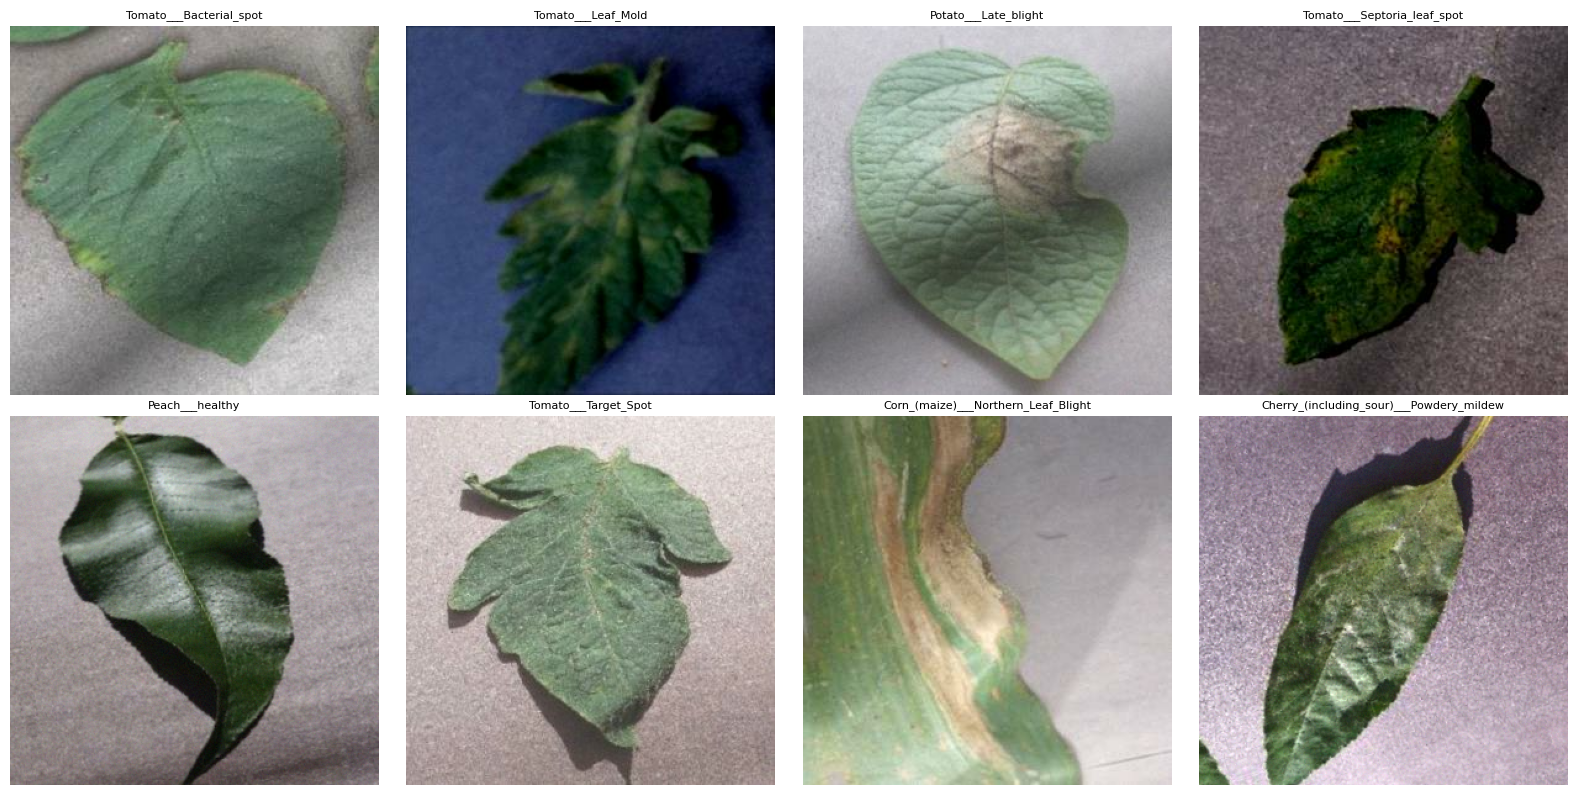

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for images, labels in train_ds.take(1):
    for i in range(8):
        ax = axes[i // 4, i % 4]
        ax.imshow(images[i].numpy())
        cls_idx = tf.argmax(labels[i]).numpy()
        ax.set_title(classes[cls_idx], fontsize=8)
        ax.axis("off")
    break

plt.tight_layout()
plt.savefig("/kaggle/working/augmentation_check.png", dpi=100)
plt.show()

In [15]:
VAL_DIR = "/kaggle/working/data_split/val"
TEST_DIR = "/kaggle/working/data_split/test"

def build_eval_dataset(directory, batch_size=BATCH_SIZE, shuffle=False):
    file_paths = []
    labels = []
    for cls in classes:
        cls_path = os.path.join(directory, cls)
        for fname in os.listdir(cls_path):
            file_paths.append(os.path.join(cls_path, fname))
            labels.append(class_to_idx[cls])

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_paths), seed=SEED)

    ds = ds.map(
        lambda p, l: load_and_preprocess(p, l, training=False),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

val_ds = build_eval_dataset(VAL_DIR)
test_ds = build_eval_dataset(TEST_DIR, shuffle=False)

print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Val batches: 340
Test batches: 340


Val batch shape: (32, 299, 299, 3)
Pixel range: 0.0 - 1.0


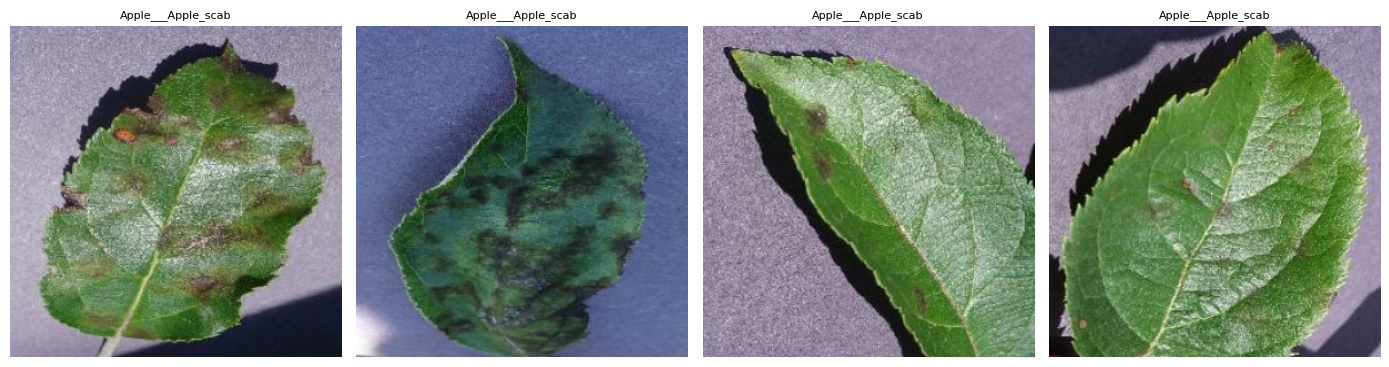

In [16]:
for images, labels in val_ds.take(1):
    print("Val batch shape:", images.shape)
    print("Pixel range:", float(tf.reduce_min(images)), "-", float(tf.reduce_max(images)))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for images, labels in val_ds.take(1):
    for i in range(4):
        cls_idx = tf.argmax(labels[i]).numpy()
        axes[i].imshow(images[i].numpy())
        axes[i].set_title(classes[cls_idx], fontsize=8)
        axes[i].axis("off")
    break
plt.tight_layout()
plt.show()

In [17]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, callbacks

NUM_CLASSES = len(classes)

base_model = InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(299, 299, 3)
)
base_model.trainable = False  # تجميد المرحلة الأولى

inputs = tf.keras.Input(shape=(299, 299, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,337,094 (85.21 MB)

 Trainable params: 534,310 (2.04 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [18]:
STEPS_PER_EPOCH = (TARGET_PER_CLASS * NUM_CLASSES) // BATCH_SIZE
VALIDATION_STEPS = tf.data.experimental.cardinality(val_ds).numpy()

cb_list = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    callbacks.ModelCheckpoint("/kaggle/working/best_stage1.keras", monitor="val_accuracy", save_best_only=True)
]

history_stage1 = model.fit(
    train_ds,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_ds,
    validation_steps=VALIDATION_STEPS,
    epochs=15,
    callbacks=cb_list
)

Epoch 1/15
   1/1425 ━━━━━━━━━━━━━━━━━━━━ 10:12:01 26s/step - accuracy: 0.0000e+00 - loss: 4.1075

I0000 00:00:1789056289.628869     154 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1425/1425 ━━━━━━━━━━━━━━━━━━━━ 719s 486ms/step - accuracy: 0.6963 - loss: 1.0032 - val_accuracy: 0.8274 - val_loss: 0.5320 - learning_rate: 0.0010
Epoch 2/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 671s 471ms/step - accuracy: 0.8015 - loss: 0.6047 - val_accuracy: 0.8457 - val_loss: 0.4647 - learning_rate: 0.0010
Epoch 3/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 664s 466ms/step - accuracy: 0.8194 - loss: 0.5419 - val_accuracy: 0.8738 - val_loss: 0.3815 - learning_rate: 0.0010
Epoch 4/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 662s 465ms/step - accuracy: 0.8268 - loss: 0.5213 - val_accuracy: 0.8212 - val_loss: 0.5322 - learning_rate: 0.0010
Epoch 5/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 659s 462ms/step - accuracy: 0.8353 - loss: 0.4981 - val_accuracy: 0.8820 - val_loss: 0.3555 - learning_rate: 0.0010
Epoch 6/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 659s 462ms/step - accuracy: 0.8381 - loss: 0.4861 - val_accuracy: 0.8864 - val_loss: 0.3471 - learning_rate: 0.0010
Epoch 7/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 649s 455ms/step - acc

In [19]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Trainable params:", sum([tf.size(w).numpy() for w in model.trainable_weights]))

Trainable params: 7707622


In [20]:
cb_list_stage2 = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
    callbacks.ModelCheckpoint("/kaggle/working/best_stage2.keras", monitor="val_accuracy", save_best_only=True)
]

history_stage2 = model.fit(
    train_ds,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_ds,
    validation_steps=VALIDATION_STEPS,
    epochs=15,
    callbacks=cb_list_stage2
)

Epoch 1/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 746s 505ms/step - accuracy: 0.8282 - loss: 0.5308 - val_accuracy: 0.9178 - val_loss: 0.2506 - learning_rate: 1.0000e-05
Epoch 2/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 704s 495ms/step - accuracy: 0.8843 - loss: 0.3418 - val_accuracy: 0.9304 - val_loss: 0.2103 - learning_rate: 1.0000e-05
Epoch 3/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 698s 490ms/step - accuracy: 0.9043 - loss: 0.2885 - val_accuracy: 0.9451 - val_loss: 0.1710 - learning_rate: 1.0000e-05
Epoch 4/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 687s 483ms/step - accuracy: 0.9134 - loss: 0.2544 - val_accuracy: 0.9472 - val_loss: 0.1565 - learning_rate: 1.0000e-05
Epoch 5/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 680s 477ms/step - accuracy: 0.9242 - loss: 0.2272 - val_accuracy: 0.9528 - val_loss: 0.1466 - learning_rate: 1.0000e-05
Epoch 6/15
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 684s 480ms/step - accuracy: 0.9299 - loss: 0.2076 - val_accuracy: 0.9530 - val_loss: 0.1410 - learning_rate: 1.0000e-05
Epoch 7/15
1425/1425 ━━━━━━━

In [21]:
best_model = tf.keras.models.load_model("/kaggle/working/best_stage2.keras")
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 58s 143ms/step - accuracy: 0.9747 - loss: 0.0797
Test Accuracy: 0.9747


In [22]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=classes))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.97      0.97       126
                                 Apple___Black_rot       0.98      1.00      0.99       125
                          Apple___Cedar_apple_rust       0.96      1.00      0.98        55
                                   Apple___healthy       0.98      0.98      0.98       329
                               Blueberry___healthy       0.98      1.00      0.99       301
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       211
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.97      0.90       103
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       239
               Corn_(maize)___Northern_Leaf_Blight       0.98      0.90      0.

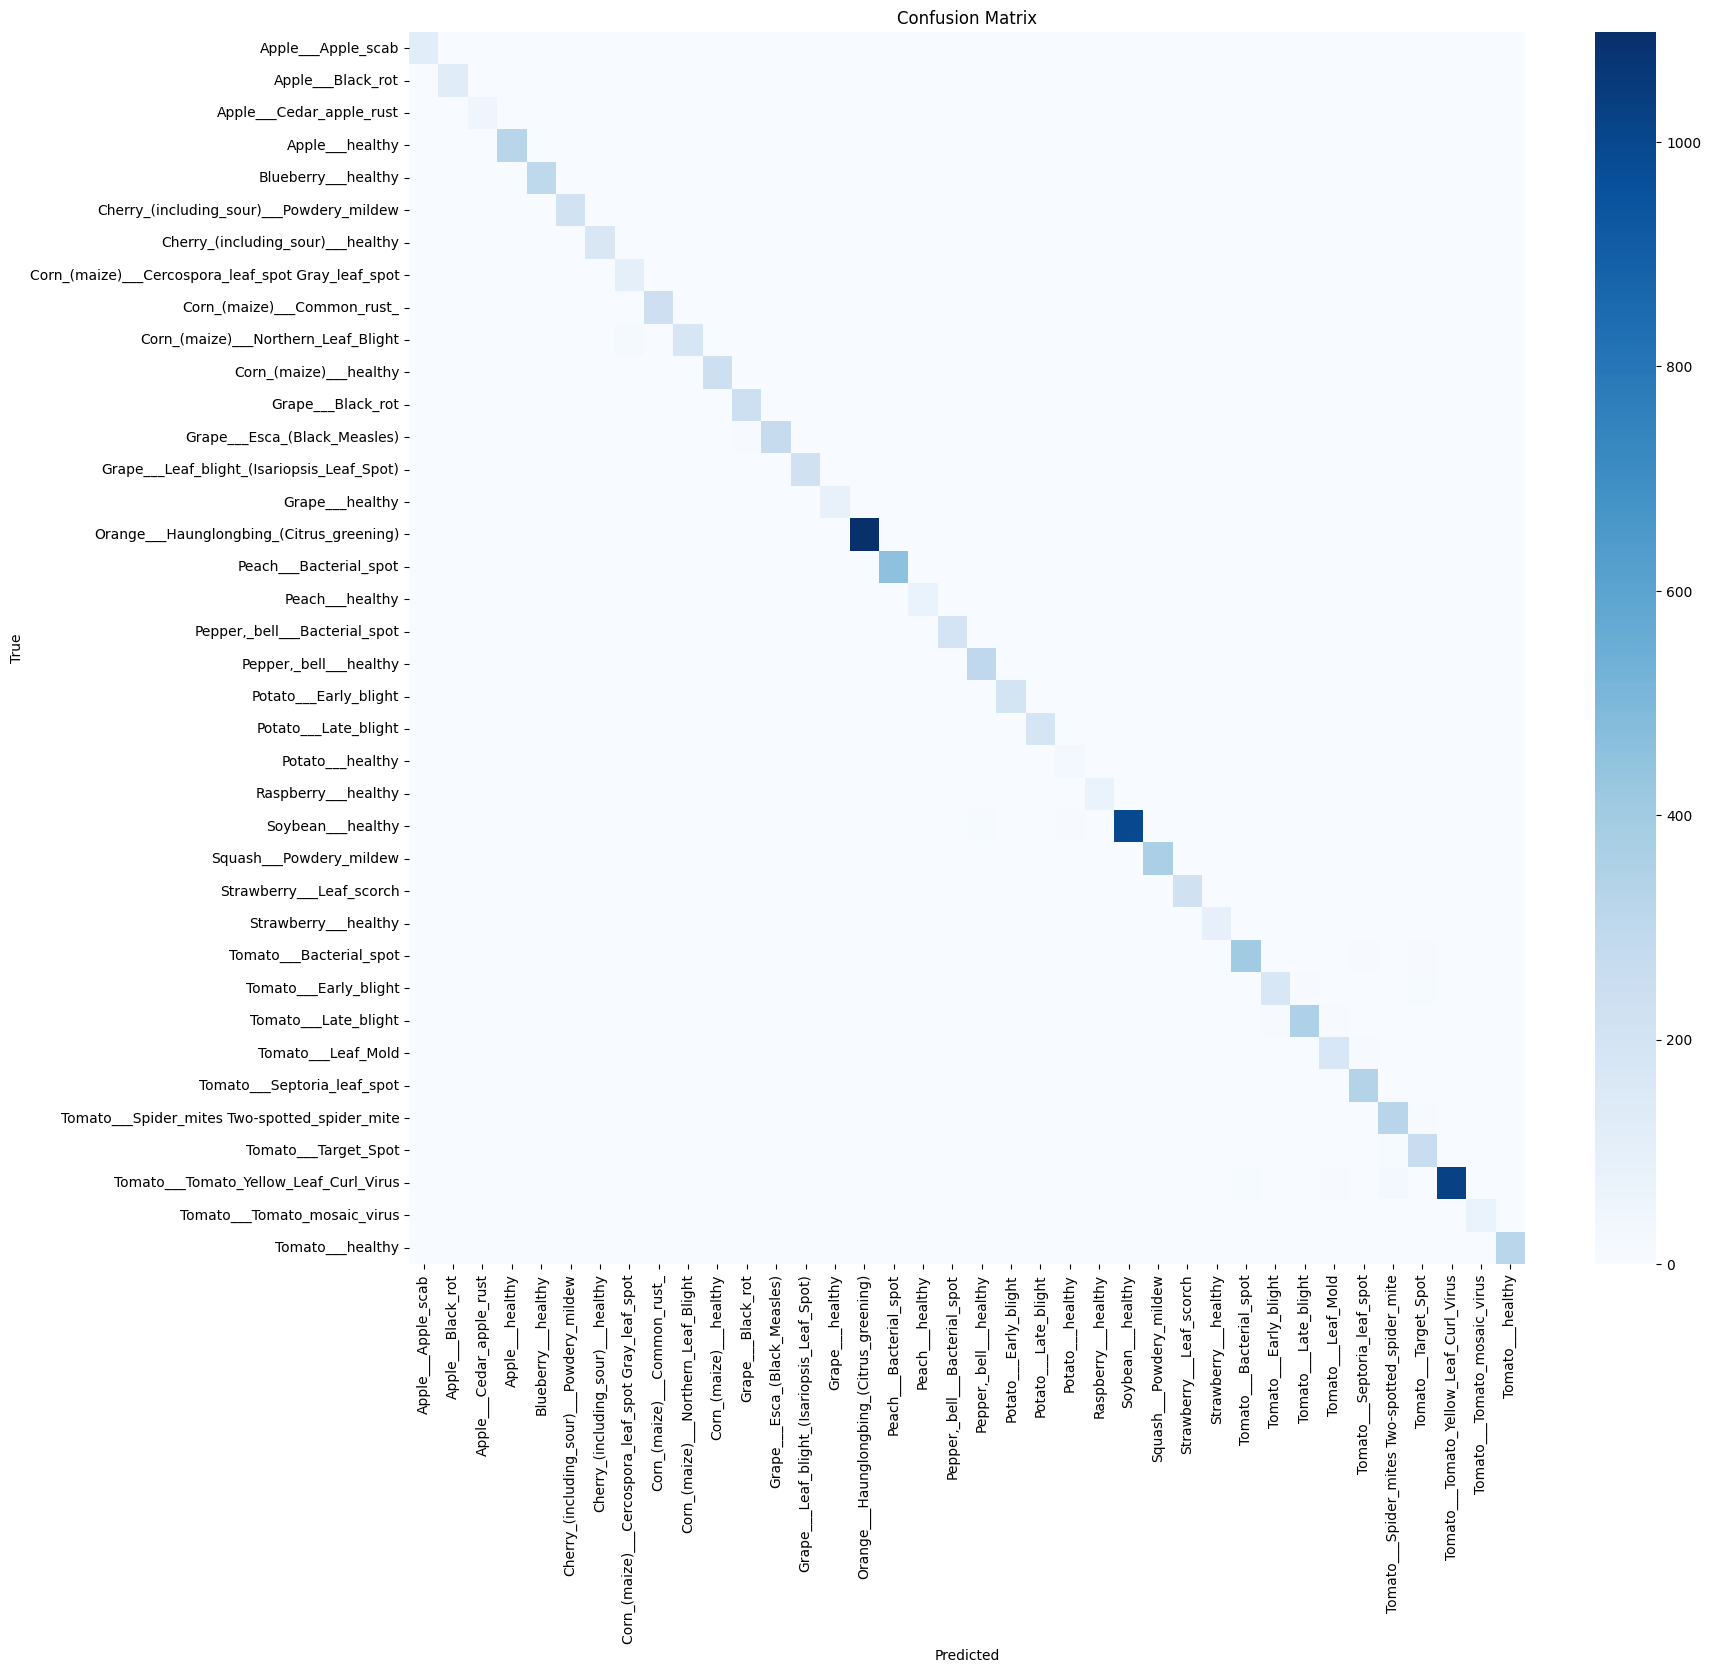

In [23]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=100)
plt.show()

In [25]:
import tensorflow as tf
import numpy as np

def apply_low_light(image, label):
    image = image * 0.4
    return tf.clip_by_value(image, 0.0, 1.0), label

def apply_strong_light(image, label):
    image = image * 1.6
    return tf.clip_by_value(image, 0.0, 1.0), label

def apply_shadow(image, label):
    h, w = 299, 299
    x1 = tf.random.uniform([], 0, w * 0.3, seed=SEED)
    x2 = tf.random.uniform([], w * 0.6, w, seed=SEED)
    mask = tf.linspace(0.0, 1.0, w)
    mask = tf.where(mask < 0.5, 0.4, 1.0)
    mask = tf.reshape(mask, (1, w, 1))
    mask = tf.tile(mask, (h, 1, 3))
    image = image * mask
    return tf.clip_by_value(image, 0.0, 1.0), label

def apply_blur(image, label):
    kernel_size = 9
    sigma = 3.0
    x = tf.range(-kernel_size // 2 + 1, kernel_size // 2 + 1, dtype=tf.float32)
    g = tf.exp(-(x ** 2) / (2 * sigma ** 2))
    g = g / tf.reduce_sum(g)
    g_kernel = tf.einsum('i,j->ij', g, g)
    g_kernel = g_kernel[:, :, tf.newaxis, tf.newaxis]
    g_kernel = tf.tile(g_kernel, [1, 1, 3, 1])
    image = tf.nn.depthwise_conv2d(image, g_kernel, strides=[1, 1, 1, 1], padding='SAME')
    return tf.clip_by_value(image, 0.0, 1.0), label

def apply_low_resolution(image, label):
    small = tf.image.resize(image, [64, 64], method='bilinear')
    back = tf.image.resize(small, [299, 299], method='bilinear')
    return tf.clip_by_value(back, 0.0, 1.0), label

robustness_subsets = {
    "normal": test_ds,
    "low_light": test_ds.map(apply_low_light, num_parallel_calls=tf.data.AUTOTUNE),
    "strong_light": test_ds.map(apply_strong_light, num_parallel_calls=tf.data.AUTOTUNE),
    "shadow": test_ds.map(apply_shadow, num_parallel_calls=tf.data.AUTOTUNE),
    "blur": test_ds.map(apply_blur, num_parallel_calls=tf.data.AUTOTUNE),
    "low_resolution": test_ds.map(apply_low_resolution, num_parallel_calls=tf.data.AUTOTUNE),
}

print("Subsets created:", list(robustness_subsets.keys()))

Subsets created: ['normal', 'low_light', 'strong_light', 'shadow', 'blur', 'low_resolution']


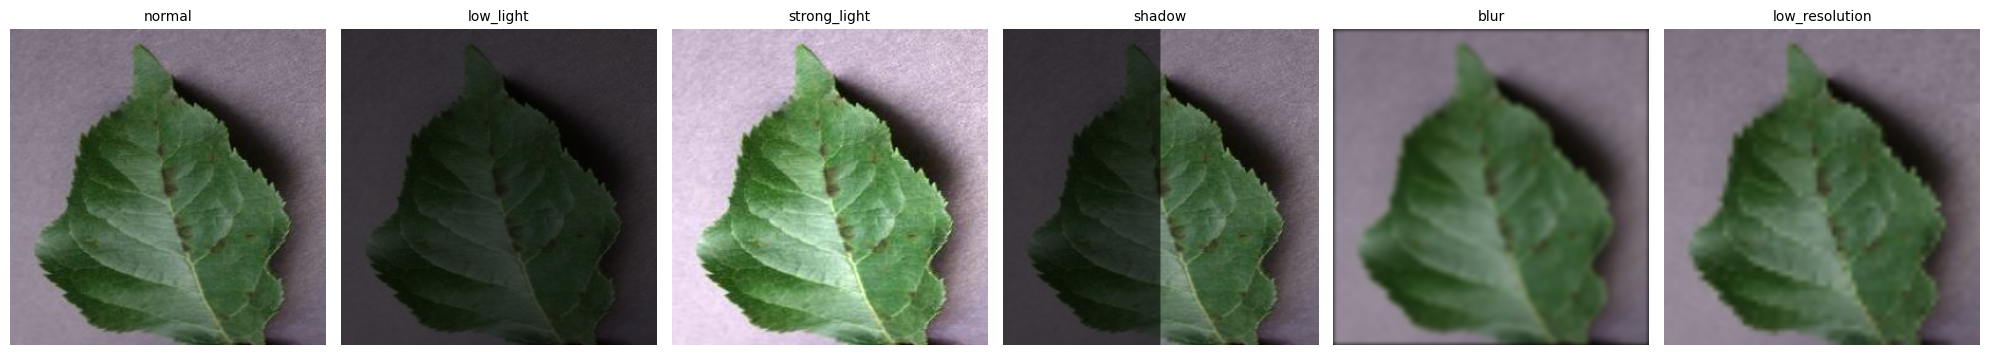

In [26]:
fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for i, (name, ds) in enumerate(robustness_subsets.items()):
    for images, labels in ds.take(1):
        axes[i].imshow(images[0].numpy())
        axes[i].set_title(name, fontsize=10)
        axes[i].axis("off")
        break
plt.tight_layout()
plt.savefig('/kaggle/working/robustness_samples.png', dpi=100)
plt.show()

In [27]:
for name, ds in robustness_subsets.items():
    for images, labels in ds.take(1):
        print(f"{name}: mean pixel = {tf.reduce_mean(images).numpy():.4f}, min = {tf.reduce_min(images).numpy():.4f}, max = {tf.reduce_max(images).numpy():.4f}")
        break

normal: mean pixel = 0.4261, min = 0.0000, max = 1.0000
low_light: mean pixel = 0.1704, min = 0.0000, max = 0.4000
strong_light: mean pixel = 0.6647, min = 0.0000, max = 1.0000
shadow: mean pixel = 0.2986, min = 0.0000, max = 0.9991
blur: mean pixel = 0.4200, min = 0.0031, max = 0.9486
low_resolution: mean pixel = 0.4261, min = 0.0018, max = 0.9710


In [28]:
robustness_results = {}

for name, ds in robustness_subsets.items():
    loss, acc = best_model.evaluate(ds, verbose=0)
    robustness_results[name] = {"loss": loss, "accuracy": acc}
    print(f"{name:20s} -> accuracy: {acc:.4f}, loss: {loss:.4f}")

normal               -> accuracy: 0.9747, loss: 0.0797
low_light            -> accuracy: 0.9685, loss: 0.0948
strong_light         -> accuracy: 0.9684, loss: 0.1011
shadow               -> accuracy: 0.9426, loss: 0.1864
blur                 -> accuracy: 0.8141, loss: 0.6549
low_resolution       -> accuracy: 0.8165, loss: 0.7143
